# Resilient EV Charging Under Disruption

## Technical report notebook for DTU 42578 Advanced Business Analytics

### Executive overview

This notebook is the main technical report for the final project. The project studies resilience in EV charging operations under disruptions on a synthetic A-B-C corridor with two fixed charging stations and relocatable mobile charging stations (MCS).

The practical question is whether adaptive control of mobile charging support can reduce queueing pain when charging demand becomes uneven, capacity drops locally, or service times inflate.

**Research question**

Can a reinforcement learning policy improve resilience in an EV charging corridor by dynamically reallocating mobile charging stations to reduce queue length and waiting time under disruptions?

The intended comparison is between:
- a fixed / no-agent baseline,
- a threshold-style rule baseline,
- and an RL-controlled mobile-charging policy.

The current local artifact set supports the full simulator and current baseline evaluations directly. It does **not** contain a current-compatible RL checkpoint for the active 27-feature, 5-action A-B-C environment, so the quantitative result sections below focus on the strongest reproducible current evidence and treat older RL artifacts only as historical context.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'exam_submission').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from exam_submission.utils.artifact_finder import artifact_table, missing_notes
from exam_submission.utils.load_artifacts import (
    load_core_configs,
    load_heldout_runs,
    load_training_history,
    load_reward_sweep_summary,
    load_suite_outputs,
)
from exam_submission.utils.plotting import (
    POLICY_LABELS,
    plot_corridor_schematic,
    plot_demand_profile,
    plot_training_history,
    plot_policy_rollout_panel,
    plot_reward_sweep,
    plot_spatial_awareness,
    plot_station_rollout_panel,
    set_report_style,
)
from exam_submission.utils.project_summary import (
    WHAT_MODEL_DOES_NOT_KNOW,
    action_table,
    environment_table,
    expected_daily_profile,
    observation_table,
    reward_table,
    rl_table,
    split_table,
)

set_report_style()
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

configs = load_core_configs()
env_cfg = configs['environment']
experiment_cfg = configs['experiment']
heldout_runs = load_heldout_runs()
suite_outputs = load_suite_outputs()
reward_sweep = load_reward_sweep_summary()
training_history, training_history_source = load_training_history()

daily_profile = expected_daily_profile(env_cfg)
artifact_df = pd.DataFrame(artifact_table())
heldout_frames = {name: payload['metrics'] for name, payload in heldout_runs.items()}
heldout_summaries = {name: payload['summary'] for name, payload in heldout_runs.items()}


## 1. Simulation goals and design philosophy

The simulator is not intended to be a perfect real-world digital twin. Its purpose is to create a controlled but operationally meaningful testbed for resilience questions:

- demand varies over the day instead of staying flat,
- morning and evening peaks create predictable congestion pressure,
- charging stations have finite plugs and stochastic service times,
- disruption events locally damage effective service capacity,
- mobile charging stations can be reallocated, but not instantaneously,
- performance is judged using queueing and waiting-time outcomes under disruption.

That design choice matters for the project story. Resilience is about whether the system continues to serve vehicles when local conditions deteriorate, not only about average utilization on a normal day.


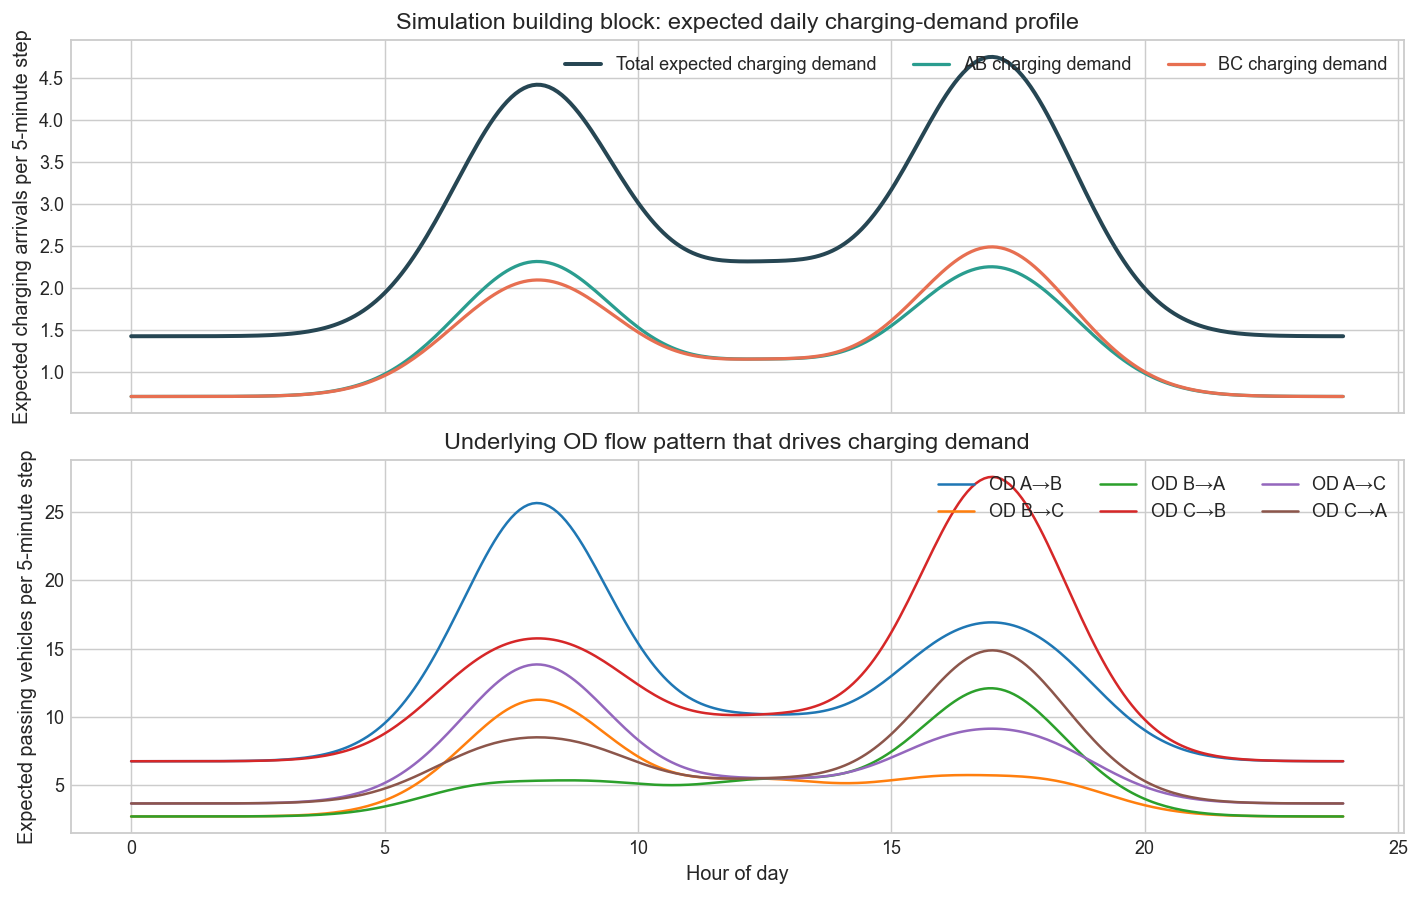

In [2]:
fig, _ = plot_demand_profile(daily_profile)
plt.show()


The first panel shows the daily charging-demand shape that the corridor is exposed to. The pattern is interpretable rather than arbitrary: a morning peak, an afternoon/evening peak, and a smaller midday bump. The second panel shows the underlying OD flow components that create this station-level charging demand.

This matters because resilience claims are more credible when disruptions are layered on top of a demand process with clear structure.


## 2. Simulation environment

The active benchmark is a synthetic line corridor with three cities and two fixed charging stations:

- City A to City B: 100 km,
- City B to City C: 100 km,
- one fixed station between A and B (`station_ab`),
- one fixed station between B and C (`station_bc`).

Episodes proceed in 5-minute decision steps. Vehicles arrive stochastically, may choose to charge, join a station queue if necessary, and start service when a plug becomes free. Mobile charging stations (MCS) provide extra chargers, but they create a real control problem because they cannot support both sides of the corridor simultaneously.

Operationally important frictions in the current environment are:

- depot-to-station travel time,
- station-to-station relocation lag,
- return-to-middle behavior,
- recharge delay before an MCS can be reused.

Those frictions make the problem spatial and delayed. The controller is not just “adding capacity”; it is committing scarce mobile support under travel and recharge constraints.


Setting,Value
Cities,A-B-C synthetic corridor
Inter-city distance,100.0 km
Fixed stations,2 (one between A-B and one between B-C)
Fixed plugs,"12 at AB, 12 at BC"
Mobile stations,Up to 10 units
Chargers per MCS,2
Decision step,5 minutes
Episode duration,2-6 days during training
Mean service time,30.0 minutes
Morning peak,8.0:00


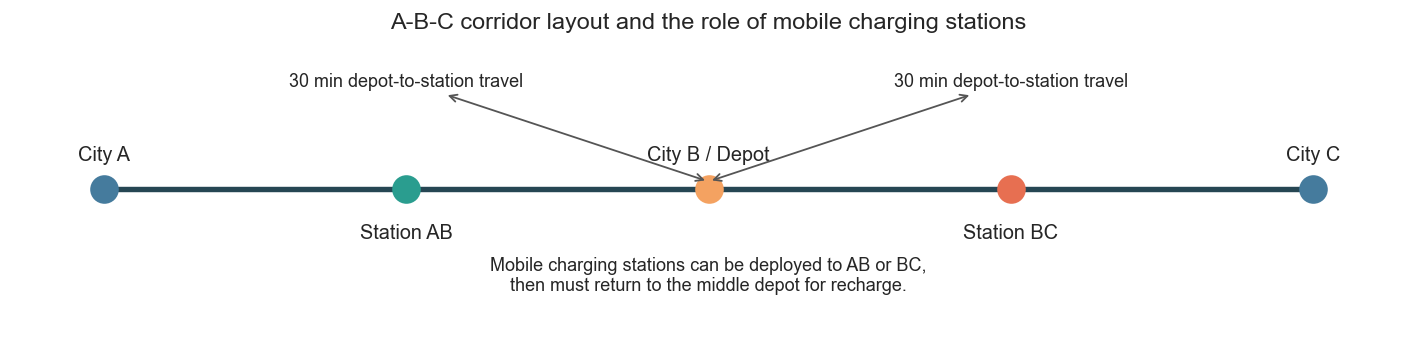

In [3]:
display(environment_table(env_cfg).style.hide(axis='index'))
fig, _ = plot_corridor_schematic()
plt.show()


The middle depot is crucial for interpretation. MCS units do not teleport. They move from the middle depot to AB or BC, can be recalled, and return for recharge. This is exactly why spatial awareness is meaningful in this project: the controller must decide *where* support is worth committing before queues become severe.


## 3. Problem formulation

The control problem is to decide how mobile charging support should be used to reduce local service pressure under normal demand variation and under disruptions.

Why is this difficult?

- fixed capacity is static while demand and disruptions are time-varying,
- the pressure may be local to AB or BC rather than system-wide,
- MCS deployment is delayed by movement and recharge,
- aggressively using MCS can improve service but also incurs operational cost.

In this project, **spatial awareness** means that a good controller should send more support toward the side of the corridor with higher local pressure, such as larger queue buildup, higher waiting times, lower effective local capacity, or a disruption directly affecting that side.


## 4. RL agent and method

The repository contains two RL paths:

- a custom `torch_dqn` / simple DQL learner, useful as a lightweight baseline learner,
- an `sb3_dqn` path, intended as the stronger final RL candidate.

Conceptually the RL loop is standard and practical:

1. observe the current corridor state,
2. choose an action for MCS commitment,
3. receive a scalar reward tied to service quality and operating cost,
4. improve the action-value function from rollout experience,
5. evaluate the learned policy in held-out simulated scenarios.

The important point for this report is not RL theory for its own sake, but whether the learned controller can improve resilience under disruption without over-using mobile capacity.

### Artifact status for the active benchmark

The current local checkout does not contain a compatible RL checkpoint for the active A-B-C benchmark after the move to the 27-dimensional observation and 5-action directional control space. That means the notebook can document the RL formulation precisely, but the reproducible **current** quantitative results below are baseline-only.


## 5. Hyperparameters

The project is config-driven. The tables below summarize the current environment and RL settings that define the active benchmark.


In [4]:
display(rl_table(configs).style.hide(axis='index'))


Hyperparameter,Value
Preferred final algorithm path,SB3 DQN
Available simple learner path,torch_dqn
Simple learner episodes,130
Simple learner gamma,0.980000
Simple learner learning rate,0.000500
Simple learner batch size,128
Replay capacity,200000
Learning starts,10000
Train frequency,4
Gradient steps,4


Two points matter for interpretation:

- the simple learner includes periodic held-out evaluation during training in principle,
- the SB3 path is treated in the repository notes as the preferred serious RL route.

That said, the absence of a current-compatible checkpoint means those settings are best interpreted as the intended final training setup rather than a fully reproducible final RL result in this checkout.


## 6. State space

The active observation is a 27-dimensional vector. It is deliberately station-aware and logistics-aware rather than purely aggregate.


In [5]:
display(observation_table().style.hide(axis='index'))


Group,Index,Feature,Meaning
Queue state,1,queue_length_ab,Current queue length at station AB.
Queue state,2,queue_length_bc,Current queue length at station BC.
Queue state,3,mean_queue_wait_ab,Mean current waiting time in the AB queue.
Queue state,4,mean_queue_wait_bc,Mean current waiting time in the BC queue.
Recent flow,5,last_arrivals_ab,Vehicles that arrived to AB in the last step.
Recent flow,6,last_arrivals_bc,Vehicles that arrived to BC in the last step.
Recent flow,7,last_starts_ab,Charging sessions started at AB in the last step.
Recent flow,8,last_starts_bc,Charging sessions started at BC in the last step.
Capacity,9,effective_plugs_ab,Effective plugs at AB after disruption and MCS effects.
Capacity,10,effective_plugs_bc,Effective plugs at BC after disruption and MCS effects.


### What the model does not know


In [6]:
for item in WHAT_MODEL_DOES_NOT_KNOW:
    display(Markdown(f'- {item}'))


- No exact future arrivals or exact future queue realizations.

- No oracle action labels or optimal allocation target.

- No foreknowledge of future random disruptions before they begin.

- No exact per-MCS battery state-of-charge representation.

- No direct remaining-disruption-time feature in the current observation.

- No explicit demand forecast beyond current local state and disruption indicators.

This is important for honesty. The agent is not given an oracle forecast of future arrivals, an exact best action label, or full future disruption knowledge. It must infer useful reallocations from local queue/capacity conditions and the currently visible disruption state.


## 7. Action space

The current action space is intentionally small and directional. That is a better match for the operational question than a large absolute-allocation table.


In [7]:
display(action_table().style.hide(axis='index'))


Action,Interpretation
hold,Keep the committed mobile-station allocation unchanged.
toward_ab,"Move one unit of commitment toward AB, either from depot or from BC."
toward_bc,"Move one unit of commitment toward BC, either from depot or from AB."
recall_ab,Recall one committed unit away from AB toward the middle depot.
recall_bc,Recall one committed unit away from BC toward the middle depot.


This design makes the control policy easier to interpret:

- `hold` means do nothing,
- `toward_ab` and `toward_bc` express directional support decisions,
- `recall_ab` and `recall_bc` reduce commitment on one side.

Compared with a large absolute allocation space, this is more learnable, more interpretable, and more consistent with movement/recharge logistics.


## 8. Reward function

The reward is not just a generic RL score. It encodes an explicit operations tradeoff between service quality and the cost of using mobile support.

### Positive terms


In [8]:
display(reward_table(env_cfg, positive=True).style.hide(axis='index'))


Term,Weight,Interpretation
served_reward_weight,1.000000,Rewards charging sessions that start service.
utilization_bonus,1.000000,Rewards productive use of available charging capacity.
spatial_deficit_alignment_bonus,24.000000,Rewards mobile capacity that covers estimated local deficits.
spatial_deficit_direction_bonus,12.000000,Rewards sending MCS in the correct corridor direction.


### Negative terms


In [9]:
display(reward_table(env_cfg, positive=False).style.hide(axis='index'))


Term,Weight,Interpretation
unmet_penalty,2.500000,Penalizes vehicles left in queue after the step.
queue_length_penalty,2.500000,Adds extra pressure against persistent queue accumulation.
queue_wait_penalty,0.020000,"Penalizes queue-wait burden, not just queue count."
local_queue_peak_penalty,1.000000,Penalizes the worst station queue in the step.
local_wait_peak_penalty,0.100000,Penalizes the worst station waiting time in the step.
active_mobile_station_cost,18.000000,Charges for keeping MCS active in the field.
activation_cost,2.000000,Charges for newly activating MCS.
adjustment_cost,0.500000,Charges for reallocating MCS commitment.
idle_capacity_penalty,0.100000,Penalizes carrying unused capacity.


The intuition is straightforward:

- serve vehicles,
- keep queues and waits low,
- prevent one station from blowing up while the average still looks acceptable,
- reward spatially useful MCS placement,
- but charge for deploying and adjusting MCS so the controller cannot treat mobile support as free.

This also means **reward and operational performance are related but not identical**. A policy can reduce queues strongly and still have a worse reward if it uses too much expensive mobile support.


## 9. Reward calibration and alternative business priorities

The reward structure can be tuned to reflect different operating priorities. That is a strength of the framework, not a flaw, as long as the choice is made explicit.

Examples of business priorities that would justify different weights are:

- minimizing queue length at almost any cost,
- enforcing a service-level target with limited MCS usage,
- penalizing active MCS-hours heavily because mobile support is expensive,
- prioritizing fairness across stations rather than only aggregate averages.

The repository itself contains evidence that this was treated as a design knob: there are separate reward-focused configs in the repo, and the local historical sweep below shows that changing queue and cost weights materially changes the operating point.


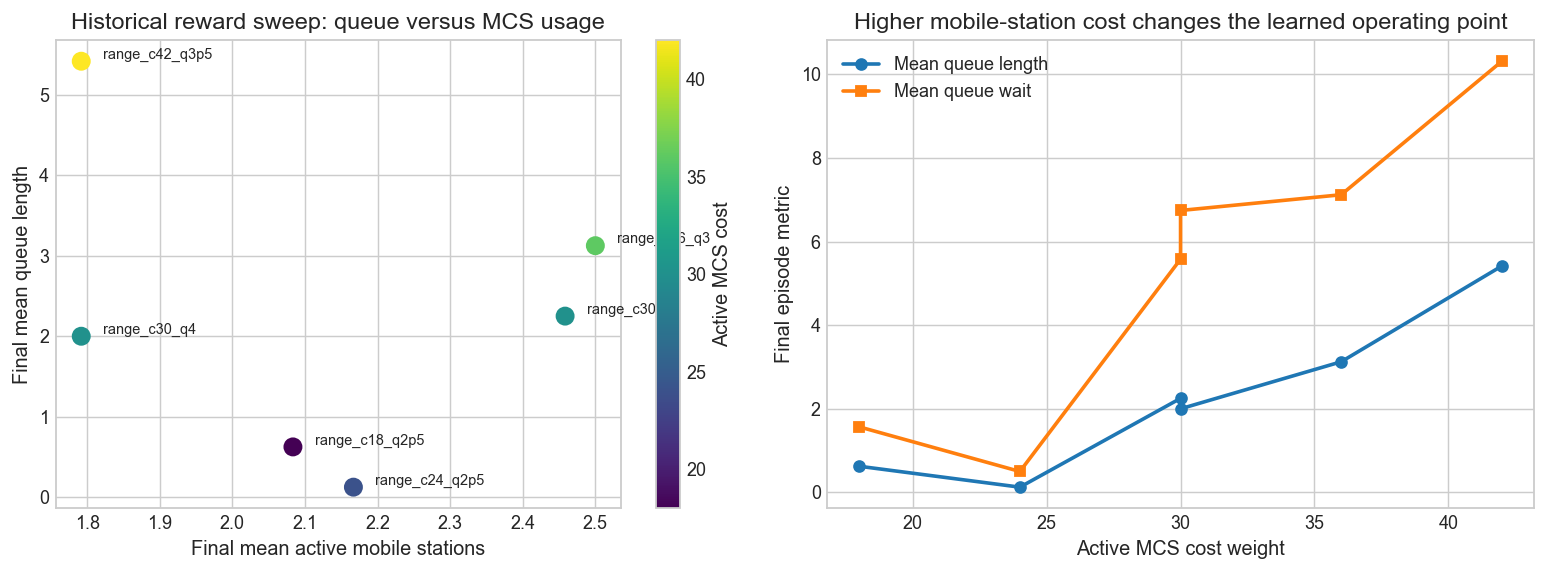

run,active_mcs_cost,queue_penalty,episodes,final_reward,final_mean_queue_length,final_mean_queue_wait_minutes,final_mean_active_mobile_stations,final_unmet_demand,final_served_demand
range_c18_q2p5,18.000000,2.500000,100,-102.930000,0.620000,1.570000,2.080000,15.000000,250.000000
range_c24_q2p5,24.000000,2.500000,100,-146.770000,0.120000,0.500000,2.170000,3.000000,232.000000
range_c30_q3,30.000000,3.000000,100,-232.350000,2.250000,5.580000,2.460000,54.000000,237.000000
range_c30_q4,30.000000,4.000000,100,-199.990000,2.000000,6.740000,1.790000,48.000000,252.000000
range_c36_q3,36.000000,3.000000,100,-309.230000,3.120000,7.120000,2.500000,75.000000,257.000000
range_c42_q3p5,42.000000,3.500000,100,-305.460000,5.420000,10.310000,1.790000,130.000000,258.000000


In [10]:
fig, _ = plot_reward_sweep(reward_sweep)
plt.show()

display(reward_sweep.round(2).style.hide(axis='index'))


The sweep does not by itself prove which reward is “correct”. Instead, it shows the key modeling fact: the policy objective can be calibrated to fit different cost assumptions. Higher mobile-station cost generally pushes the controller toward less deployment and worse queue outcomes, while lower cost permits more active support.

This is exactly why the final exam discussion should separate:

- operational metrics such as queue and waiting time,
- the chosen reward calibration,
- and the business meaning of MCS cost.


## 10. Training, validation, and test setup

The intended experimental design is seed-driven rather than based on one hand-picked scenario.


In [11]:
display(split_table(experiment_cfg).style.hide(axis='index'))


Split,Purpose
Training,Randomized 2-6 day episodes from seeds 0-9999
Validation,Held-out same-distribution seeds starting at 10000
Test ID,Unseen deployment-style seeds starting at 20000 with 3-5 day overrides
Test stress,Named scripted disruption scenarios
Held-out rollout,One fixed unseen test_id seed for direct time-series comparison


The project notes emphasize a clear separation between:

- randomized training episodes,
- held-out same-distribution validation,
- unseen `test_id` seeds meant to mimic deployment-style evaluation,
- and separate stress scenarios for robustness.

This is a good evaluation philosophy even when there is no hyperparameter search or early stopping, because it distinguishes training exposure from final held-out behavior.


## 11. Training and evaluation learning curves

This section uses the **training-time history artifact only**. That means the relevant file is `outputs/mobile_mcs_line_abc/rl/history.json` from the training job, not the large final evaluation-suite outputs.

If that current history file exists, the notebook will use it directly and plot:

- train reward,
- evaluation reward collected during training,
- train TD loss,
- evaluation TD loss collected during training.

If the current history file is missing, the notebook falls back to a historical local artifact and labels it clearly as historical context only.


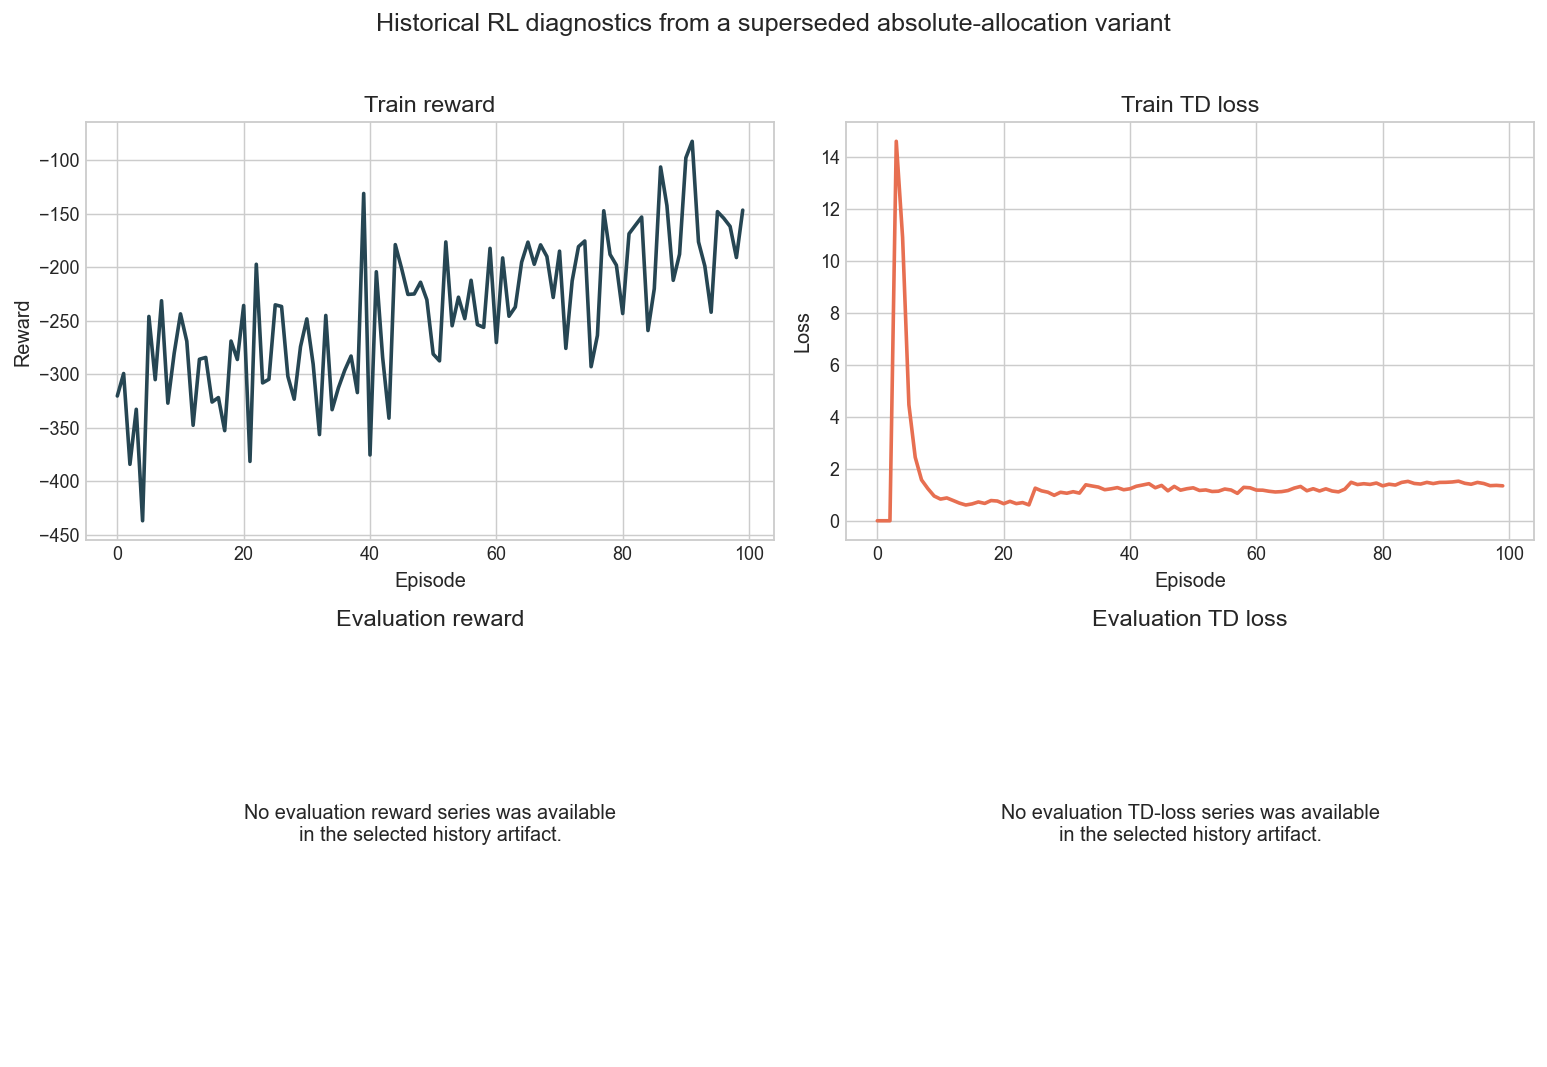

Status,Value,Interpretation
Training history source,Historical fallback artifact,The current training-only history file was not found locally.
Current compatible RL training history,No,Current learning curves cannot be reconstructed from local artifacts yet.
Training-time evaluation reward curve,No,Held-out eval reward is unavailable until a new training run produces history.json.
Training-time evaluation TD-loss curve,No,Held-out eval TD loss is unavailable until a new training run produces history.json.
Large final evaluation suite required for this plot,No,"Even in this fallback case, the large final evaluation suite is still not needed for this section."


In [12]:
fig, _ = plot_training_history(training_history, source=training_history_source)
plt.show()

if training_history_source == 'current':
    artifact_status = pd.DataFrame({
        'Status': [
            'Training history source',
            'Current compatible RL training history',
            'Training-time evaluation reward curve',
            'Training-time evaluation TD-loss curve',
            'Large final evaluation suite required for this plot',
        ],
        'Value': [
            'outputs/mobile_mcs_line_abc/rl/history.json',
            'Yes',
            'Yes' if pd.DataFrame(training_history).get('eval_mean_reward', pd.Series(dtype=float)).notna().any() else 'No',
            'Yes' if pd.DataFrame(training_history).get('eval_td_loss', pd.Series(dtype=float)).notna().any() else 'No',
            'No',
        ],
        'Interpretation': [
            'The notebook is using the current training-only artifact.',
            'This is the correct artifact for train/eval learning curves in the active benchmark.',
            'Evaluation reward comes from periodic held-out evaluation during training.',
            'Evaluation TD loss comes from periodic held-out evaluation during training.',
            'The full validation/test/stress suite is not needed for this section.',
        ],
    })
else:
    artifact_status = pd.DataFrame({
        'Status': [
            'Training history source',
            'Current compatible RL training history',
            'Training-time evaluation reward curve',
            'Training-time evaluation TD-loss curve',
            'Large final evaluation suite required for this plot',
        ],
        'Value': [
            'Historical fallback artifact',
            'No',
            'No',
            'No',
            'No',
        ],
        'Interpretation': [
            'The current training-only history file was not found locally.',
            'Current learning curves cannot be reconstructed from local artifacts yet.',
            'Held-out eval reward is unavailable until a new training run produces history.json.',
            'Held-out eval TD loss is unavailable until a new training run produces history.json.',
            'Even in this fallback case, the large final evaluation suite is still not needed for this section.',
        ],
    })

display(artifact_status.style.hide(axis='index'))


The practical implication is that the notebook can document the *evaluation design* rigorously, but it cannot make a defensible final RL-learning claim for the active environment without retraining or recovering a compatible checkpoint/history pair.


## 12. Simulation rollout comparison

The strongest reproducible current comparison is a fixed unseen 5-day `test_id` rollout using the active line-corridor implementation.

Because the RL artifact is missing, this section compares three baselines that *are* available and current:

- fixed / no-agent (`mobile_noop`),
- threshold baseline,
- reactive baseline.

This still answers an important resilience question: does adaptive mobile support materially reduce queueing pain under disruptions, and how costly is a more aggressive control rule?


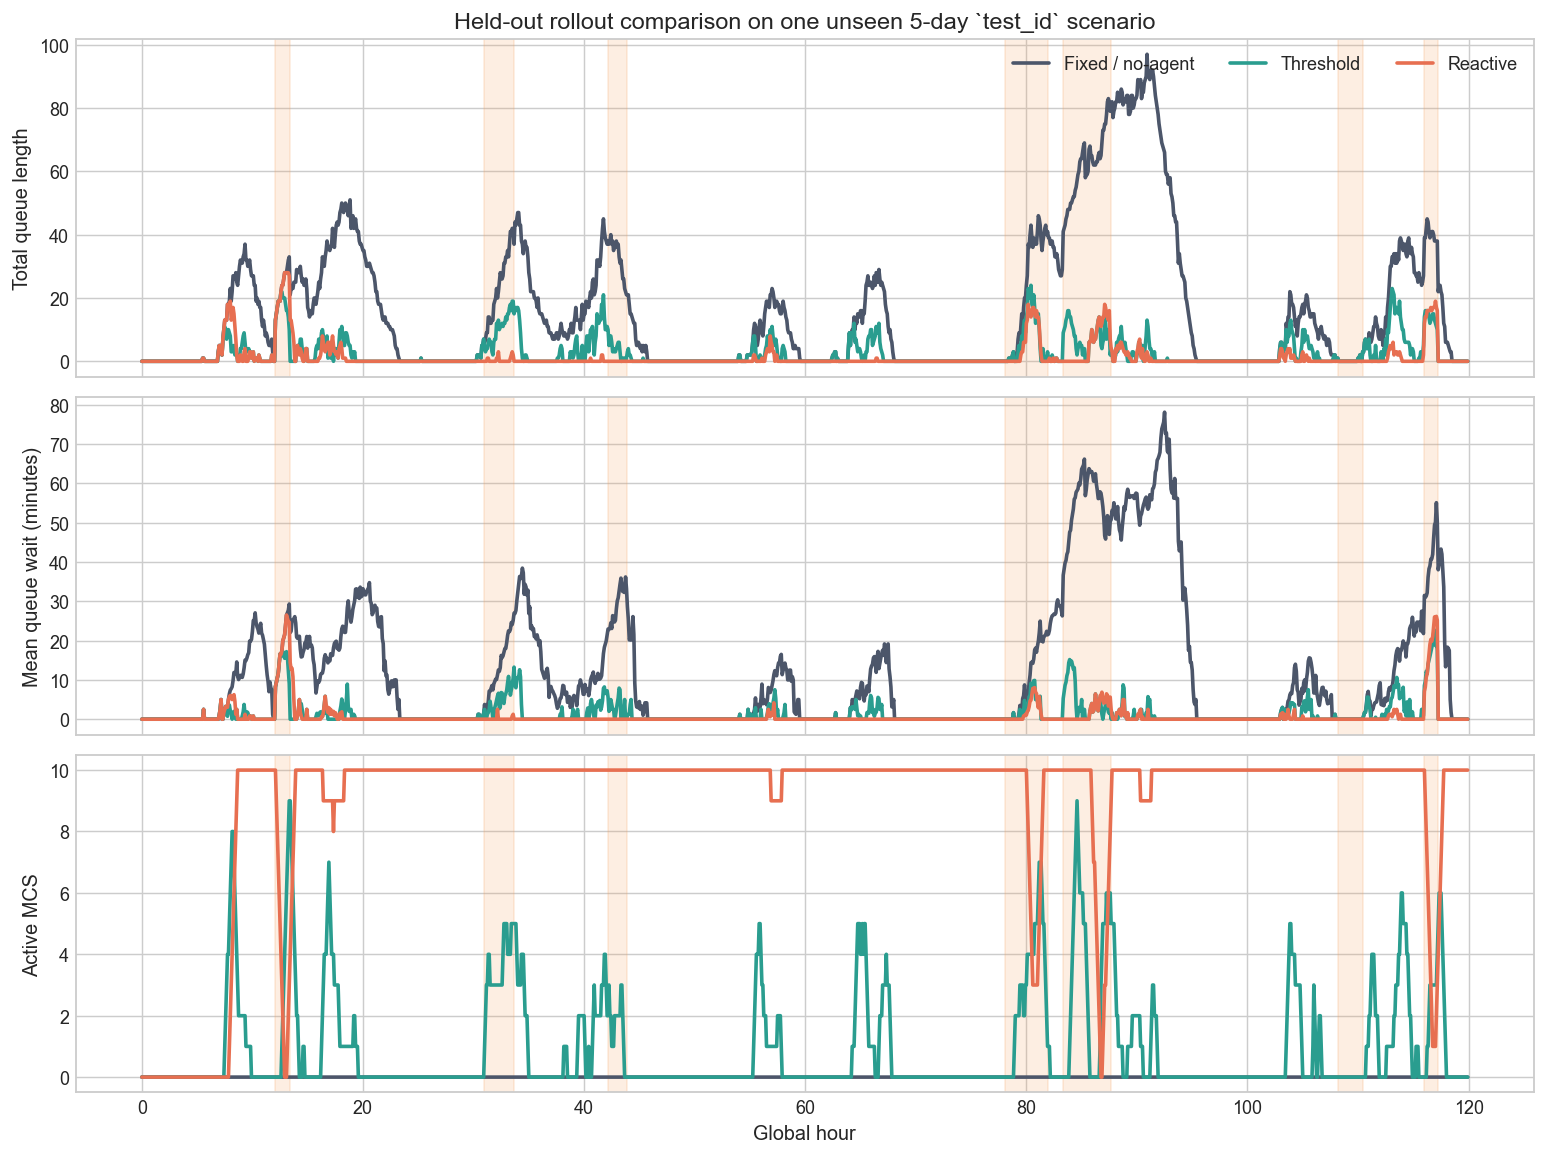

In [13]:
fig, _ = plot_policy_rollout_panel(heldout_frames)
plt.show()


The difference is immediate. Leaving all mobile support unused creates large queue accumulation and long waiting times over the held-out horizon. Both adaptive baselines help substantially.

The reactive rule is the strongest queue-reduction baseline in the current held-out rollout, but it keeps many MCS active for most of the episode. The threshold rule is more frugal: it achieves a large reduction in queueing while using much less mobile support.


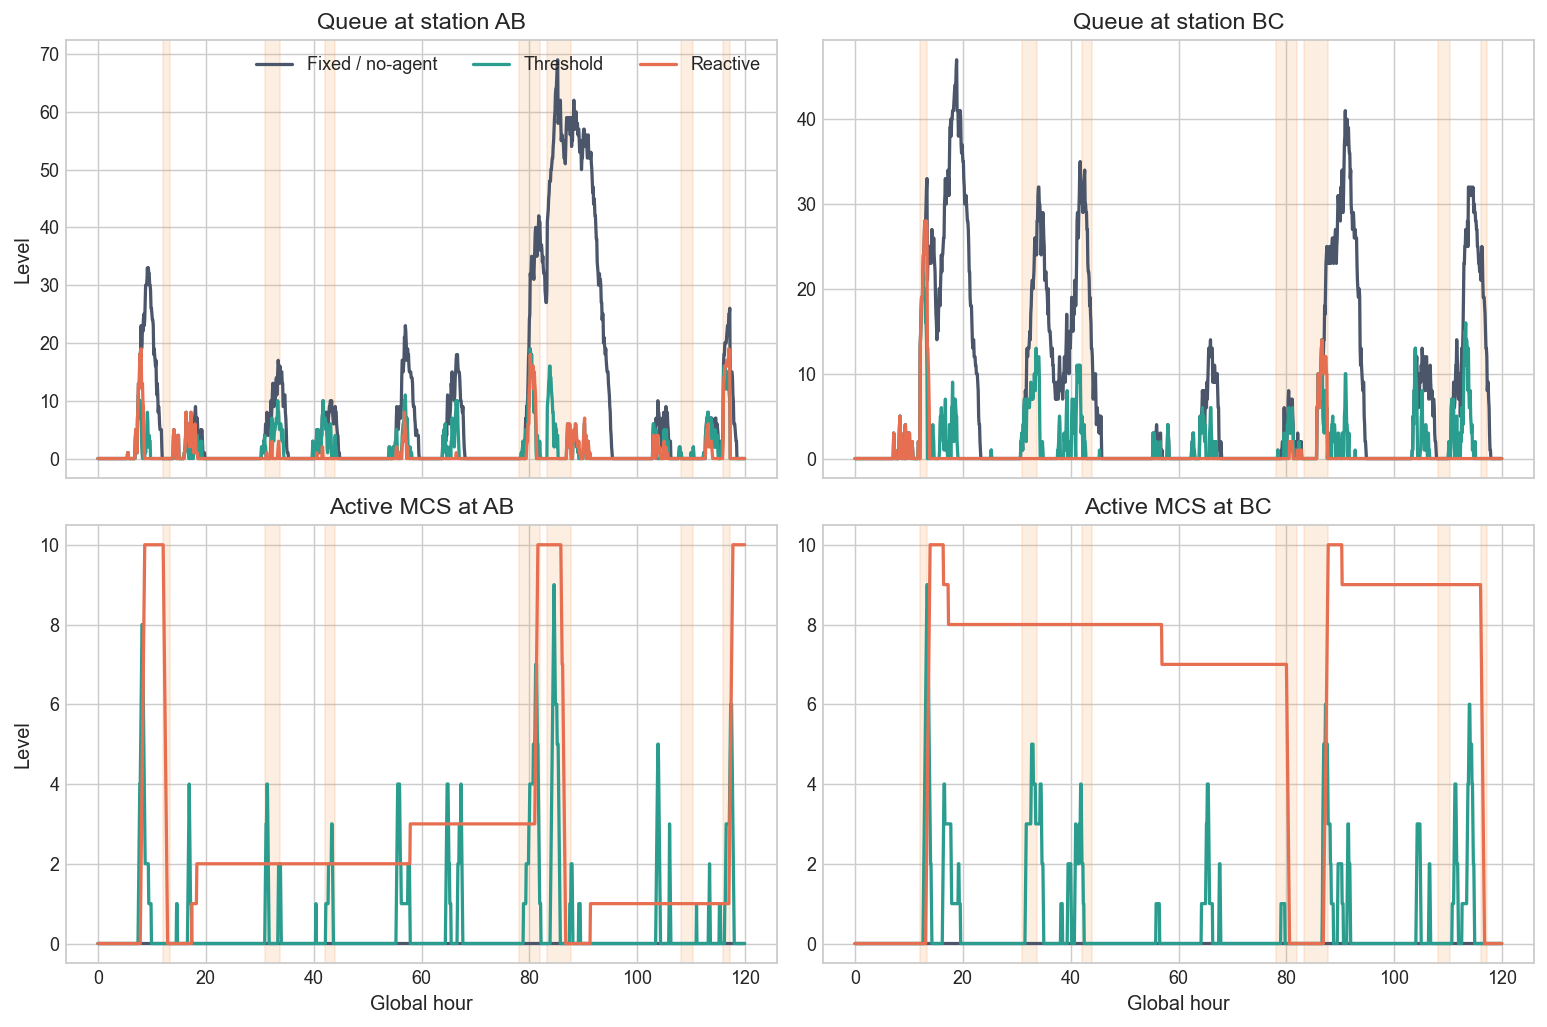

In [14]:
fig, _ = plot_station_rollout_panel(heldout_frames)
plt.show()


The station-level view makes the resilience story clearer. Congestion is local, not only aggregate. The adaptive rules keep AB and BC from diverging as severely as the fixed baseline, which is exactly the kind of local resilience behavior the project was designed to test.


## 13. Summary metrics table

The table below aggregates the current held-out rollout results and computes improvement relative to the fixed/no-agent baseline.


In [15]:
heldout_rows = []
fixed_df = heldout_frames['mobile_noop']
fixed_mean_queue = fixed_df['queue_length'].mean()
fixed_mean_wait = fixed_df['queue_wait_mean_minutes'].mean()
fixed_reward = fixed_df['reward'].sum()
for policy_name, frame in heldout_frames.items():
    heldout_rows.append({
        'Policy': POLICY_LABELS[policy_name],
        'Mean queue length': frame['queue_length'].mean(),
        'Peak queue length': frame['queue_length'].max(),
        'Mean wait (min)': frame['queue_wait_mean_minutes'].mean(),
        'Peak wait (min)': frame['queue_wait_mean_minutes'].max(),
        'Unmet demand proxy (queue sum)': frame['queue_length'].sum(),
        'Mean active MCS': frame['num_active_mobile_stations'].mean(),
        'MCS-hours': frame['num_active_mobile_stations'].sum() * 5 / 60,
        'Reward (sum)': frame['reward'].sum(),
    })
heldout_table = pd.DataFrame(heldout_rows)
heldout_table['Queue improvement vs fixed (%)'] = 100 * (fixed_mean_queue - heldout_table['Mean queue length']) / fixed_mean_queue
heldout_table['Wait improvement vs fixed (%)'] = 100 * (fixed_mean_wait - heldout_table['Mean wait (min)']) / fixed_mean_wait
heldout_table['Reward diff vs fixed'] = heldout_table['Reward (sum)'] - fixed_reward

display(heldout_table.round(2).style.hide(axis='index'))


Policy,Mean queue length,Peak queue length,Mean wait (min),Peak wait (min),Unmet demand proxy (queue sum),Mean active MCS,MCS-hours,Reward (sum),Queue improvement vs fixed (%),Wait improvement vs fixed (%),Reward diff vs fixed
Fixed / no-agent,16.600000,97.000000,12.370000,78.140000,23898.000000,0.000000,0.000000,-15969.370000,0.000000,0.000000,0.000000
Threshold,2.650000,24.000000,1.280000,22.690000,3809.000000,0.950000,113.500000,-4202.840000,84.060000,89.620000,11766.530000
Reactive,1.290000,28.000000,0.710000,26.520000,1855.000000,8.980000,1077.080000,-24060.170000,92.240000,94.250000,-8090.800000


Two insights stand out.

First, adaptive mobile support clearly improves resilience relative to the fixed baseline. Second, the *best queue reduction* and the *best reward* are not the same thing. The reactive baseline is operationally strongest on queue and wait metrics, but the threshold baseline is more cost-efficient because it uses far fewer mobile-station hours.


## 14. Reduced multi-seed evaluation and stress scenarios

To avoid relying only on one illustrative rollout, a reduced current baseline-only suite was generated over multiple unseen `test_id` seeds plus four stress scenarios.


In [16]:
test_id_summary = suite_outputs['test_id_summary'].copy()
test_id_summary['Policy'] = test_id_summary['policy_alias'].map({'fixed':'Fixed / no-agent', 'threshold':'Threshold', 'reactive':'Reactive'})
summary_cols = ['Policy','mean_queue_length','mean_queue_wait_minutes','peak_queue_length','peak_queue_wait_minutes','served_demand','unmet_demand','mean_active_mobile_stations','mcs_hours','reward']
display(test_id_summary[summary_cols].round(2).style.hide(axis='index'))


Policy,mean_queue_length,mean_queue_wait_minutes,peak_queue_length,peak_queue_wait_minutes,served_demand,unmet_demand,mean_active_mobile_stations,mcs_hours,reward
Fixed / no-agent,17.740000,13.430000,89.220000,71.910000,2959.330000,19366.390000,0.000000,0.000000,-13156.330000
Reactive,2.210000,1.080000,35.280000,22.360000,2962.440000,2374.330000,7.980000,739.550000,-17240.750000
Threshold,3.650000,1.820000,41.830000,25.590000,2961.220000,3987.330000,1.090000,99.500000,-4155.960000


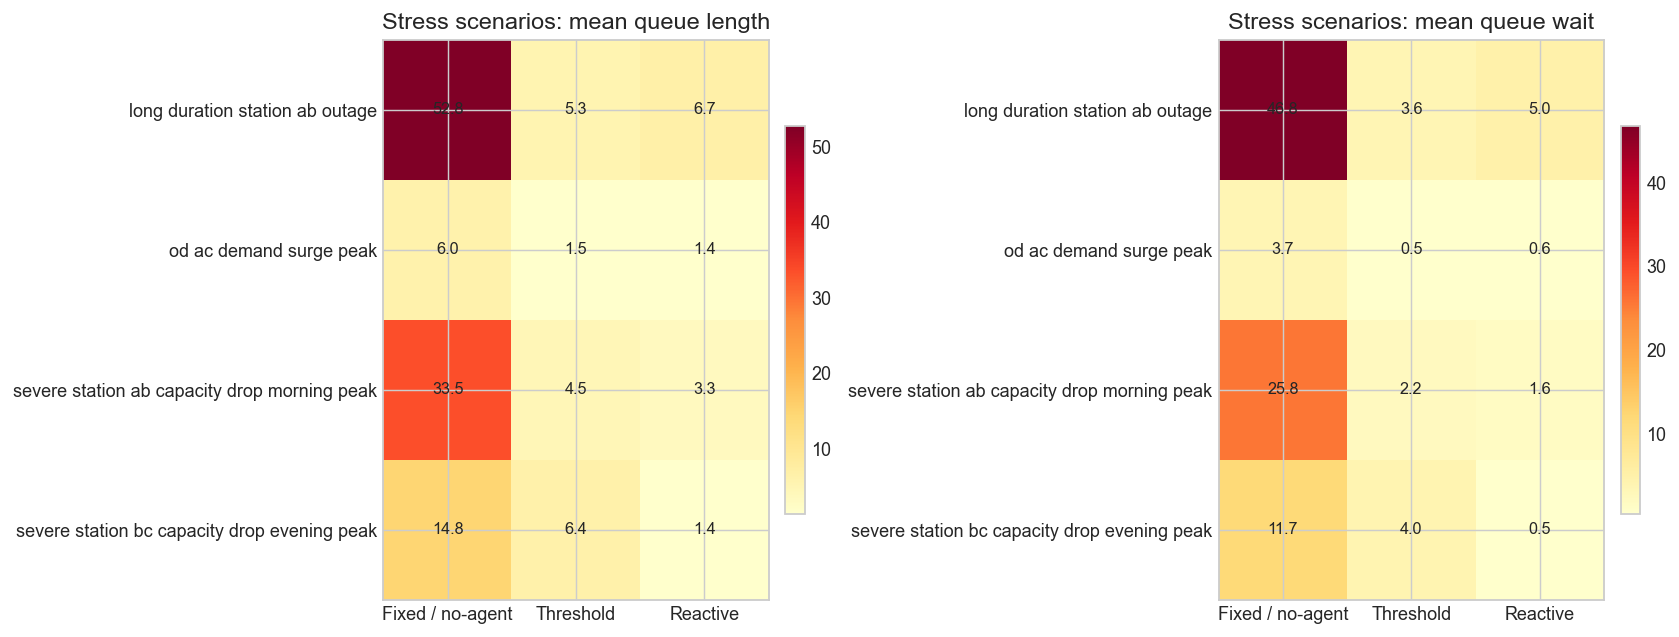

In [17]:
stress = suite_outputs['test_stress_summary'].copy()
pivot_q = stress.pivot(index='stress_scenario', columns='policy_alias', values='mean_queue_length').loc[:, ['fixed','threshold','reactive']]
pivot_w = stress.pivot(index='stress_scenario', columns='policy_alias', values='mean_queue_wait_minutes').loc[:, ['fixed','threshold','reactive']]
column_labels = ['Fixed / no-agent', 'Threshold', 'Reactive']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pivot, title in [
    (axes[0], pivot_q, 'Stress scenarios: mean queue length'),
    (axes[1], pivot_w, 'Stress scenarios: mean queue wait'),
]:
    image = ax.imshow(pivot.to_numpy(), aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(pivot.shape[1]), column_labels)
    ax.set_yticks(range(pivot.shape[0]), [label.replace('_', ' ') for label in pivot.index])
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:.1f}", ha='center', va='center', fontsize=9)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


The reduced multi-seed evidence tells the same story as the single held-out rollout:

- fixed capacity alone is fragile under severe local disruptions,
- threshold control is a strong cost-sensitive adaptive baseline,
- the reactive rule often reduces queues even further, but with much heavier MCS usage and substantially worse reward once deployment cost is counted.

This is one of the clearest project insights: a resilience intervention can look excellent on queue metrics and still be economically unattractive under a cost-sensitive reward.


## 15. Spatial awareness

A spatially aware controller should increase support toward AB when AB has higher local service pressure and toward BC when BC is more stressed.

The current active artifacts allow this to be checked directly because the rollout exports station-level queues, local deficit estimates, and allocation bias.


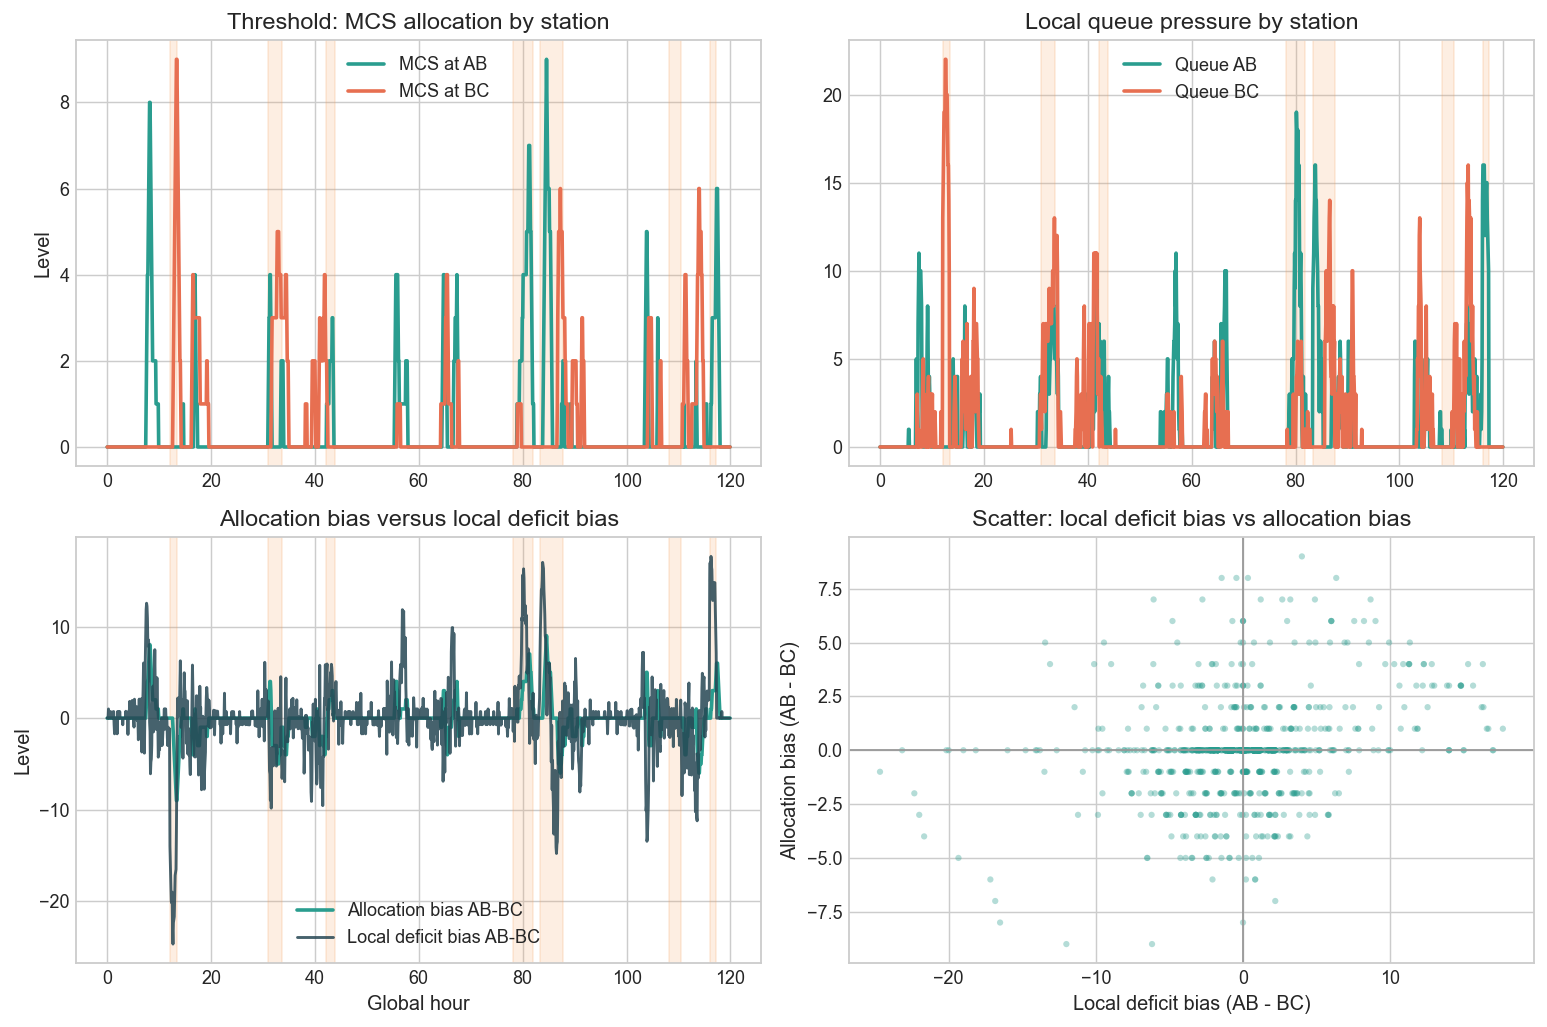

In [18]:
fig, _ = plot_spatial_awareness(heldout_frames['mobile_threshold'], 'mobile_threshold')
plt.show()


For the threshold baseline, the relationship between local deficit bias and allocation bias is clearly positive. That is not perfect one-to-one tracking, but it is directionally meaningful and consistent with the intended spatial logic of the corridor.


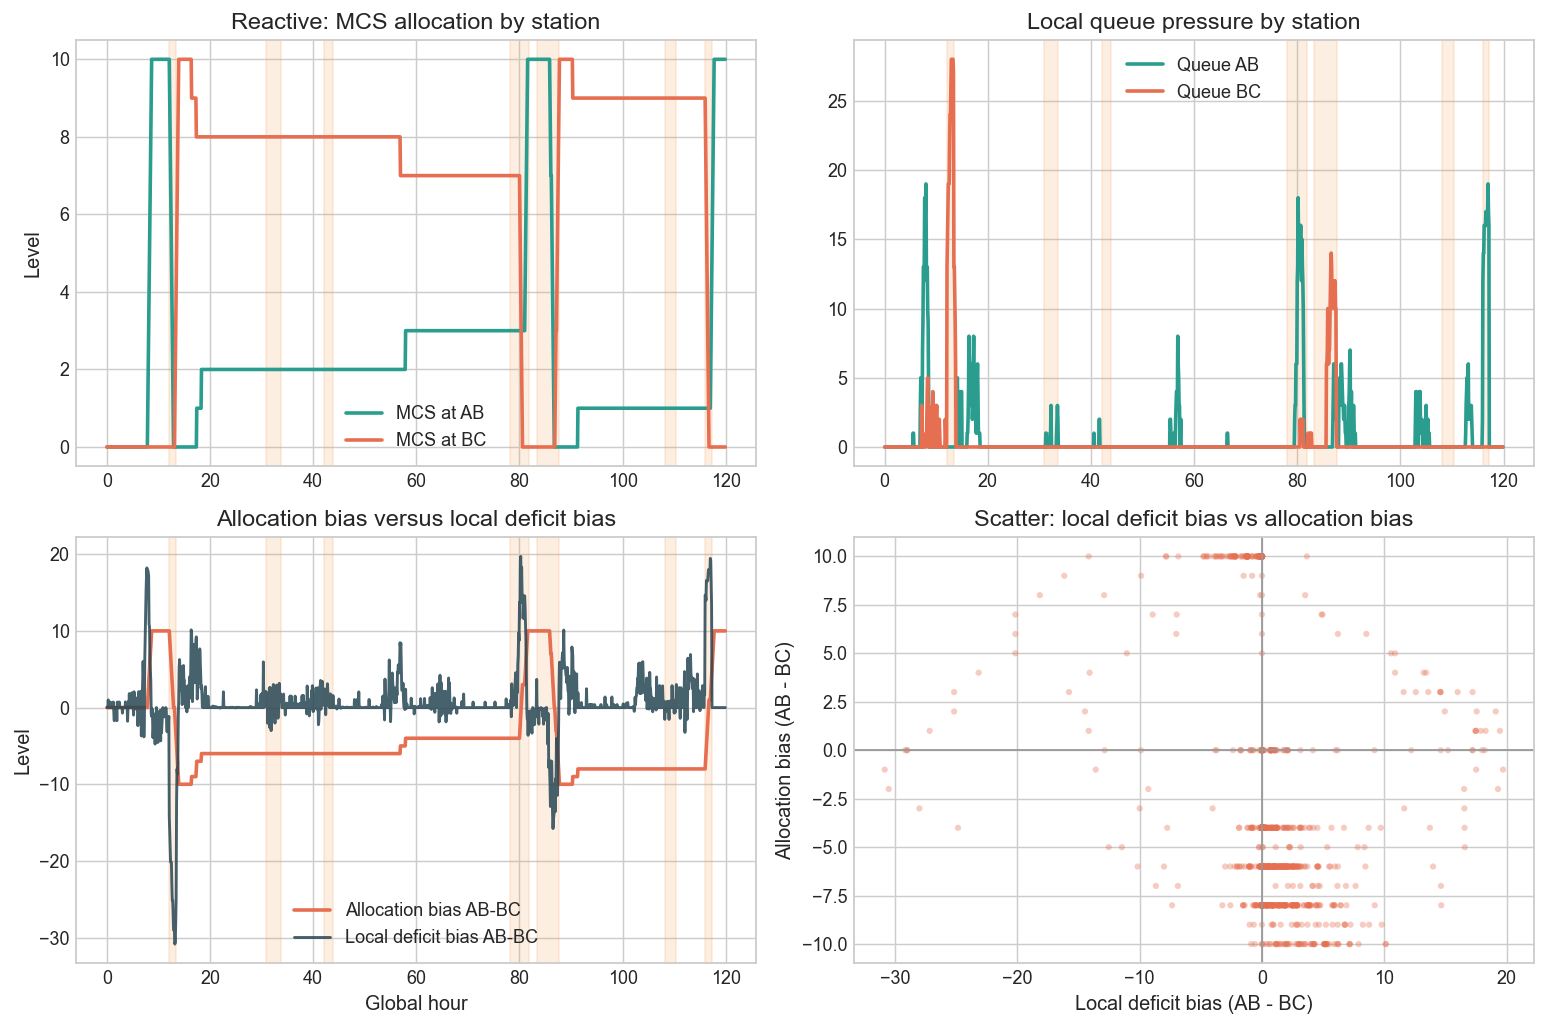

In [19]:
fig, _ = plot_spatial_awareness(heldout_frames['mobile_reactive'], 'mobile_reactive')
plt.show()


In [20]:
spatial_rows = []
for policy_name, frame in heldout_frames.items():
    spatial_rows.append({
        'Policy': POLICY_LABELS[policy_name],
        'Corr(local deficit bias, allocation bias)': frame['local_deficit_bias_ab_minus_bc'].corr(frame['allocation_bias_ab_minus_bc']),
        'Corr(expected demand bias, allocation bias)': frame['expected_demand_bias_ab_minus_bc'].corr(frame['allocation_bias_ab_minus_bc']),
        'Corr(committed bias, allocation bias)': frame['committed_mobile_stations_bias_ab_minus_bc'].corr(frame['allocation_bias_ab_minus_bc']),
    })
spatial_df = pd.DataFrame(spatial_rows)
display(spatial_df.round(3).style.hide(axis='index'))


Policy,"Corr(local deficit bias, allocation bias)","Corr(expected demand bias, allocation bias)","Corr(committed bias, allocation bias)"
Fixed / no-agent,nan,nan,nan
Threshold,0.288000,0.374000,0.762000
Reactive,-0.175000,0.086000,0.962000


The spatial-awareness evidence is mixed in an informative way.

- The threshold baseline shows the clearest positive alignment with local service pressure.
- The reactive baseline is aggressive and very active, but its deficit-to-allocation correlation is weaker because it tends to flood capacity into the system and keep it active for long periods.
- The fixed baseline has no spatial response by construction.

So the project should not claim “perfect spatial awareness”. A stronger statement would be: **the current simulator and metrics can reveal spatial behavior clearly, and the threshold rule shows the cleanest interpretable directional response among the available current policies.**


## 16. Missing pieces, failures, and limitations

Several limitations are important for an examiner to see explicitly.

1. **No current-compatible RL artifact is available locally.** The active benchmark can be described precisely, but a final RL-vs-baseline quantitative claim is not reproducible from this checkout without retraining or recovering the missing checkpoint/history.
2. **Current queue-breach metrics are not instrumented as service-level targets in the active line corridor.** The exported breach columns are therefore zero and should not be over-interpreted.
3. **The simulator is stylized.** It is realistic enough to study operational tradeoffs, but it is still a synthetic environment rather than a calibrated production deployment model.
4. **Reward sensitivity is real.** The reward sweep and the baseline comparisons both show that cost weights change the preferred policy substantially.
5. **Spatial response is meaningful but imperfect.** A controller can reduce total queues without cleanly matching local deficit patterns at every step because demand symmetry, travel lag, recharge delay, and cost all matter.
6. **Baselines matter.** The reactive baseline is so strong on queue reduction that any future RL claim should be benchmarked against it, not only against the no-agent baseline.


## 17. Conclusion

The project successfully builds a coherent resilience testbed for EV charging operations under disruption. The simulator captures local queueing pressure, daily demand structure, multiple disruption types, and mobile-support logistics in a form that is interpretable and reproducible.

On the **current reproducible artifacts**, adaptive mobile support clearly improves resilience relative to fixed-only operation. The threshold baseline delivers a strong cost-sensitive tradeoff, while the reactive baseline delivers the strongest queue reduction at a much higher mobile-support cost. That distinction is valuable because it shows why reward design and business priorities matter.

For the original RL research question, the honest answer from this checkout is partial: the RL formulation is well specified, but a current-compatible RL checkpoint is missing, so the notebook cannot make a final defensible claim that the active RL agent outperforms current baselines. The next concrete step would be to train or recover an SB3 DQN policy for the active 27-feature, 5-action environment and evaluate it against the threshold and reactive baselines already documented here.


## Appendix: Artifact status

The table below documents exactly which artifacts were selected for this notebook and which important current RL artifacts were missing.


In [21]:
display(artifact_df.style.hide(axis='index'))
for note in missing_notes():
    display(Markdown(f'- {note}'))


path,type,exists,note
data/configs/env_mobile_mcs_line_abc_current.yaml,config,True,Current active line-corridor environment config.
data/configs/experiment_mobile_mcs_line_abc_current.yaml,config,True,Current active line-corridor environment config.
data/configs/dqn_mobile_simple.yaml,config,False,Current torch DQN/simple learner config including evaluation cadence.
data/configs/dqn_mobile_sb3.yaml,config,False,Current SB3 DQN config; used for algorithm description only because no compatible checkpoint was found.
data/configs/mobile_mcs_line_abc.yaml,config,False,"Experiment split config with validation, test_id, and stress suite definitions."
data/generated/heldout/mobile_noop_comparison_timestep_metrics.csv,generated_eval,True,Current held-out fixed/no-agent rollout on the active line corridor.
data/generated/heldout/mobile_threshold_comparison_timestep_metrics.csv,generated_eval,True,Current held-out threshold-baseline rollout on the active line corridor.
data/generated/heldout/mobile_reactive_comparison_timestep_metrics.csv,generated_eval,True,Current held-out reactive-baseline rollout on the active line corridor.
data/generated/evaluation_suites_small/test_id_summary.csv,generated_eval,True,Reduced multi-seed test_id baseline summary used for robustness tables.
data/generated/evaluation_suites_small/test_stress_summary.csv,generated_eval,True,Reduced stress-suite baseline summary used for disruption robustness discussion.


- No current-compatible RL checkpoint was found for the active 27-feature / 5-action A-B-C environment.

- No current-compatible RL history with eval_mean_reward and eval_td_loss was found in local artifacts.

- Queue-wait target breach metrics are zero in the active line-corridor outputs because the current environment does not instrument a nonzero queue-wait target.